### Seminar #3. The Materials Project API

#### Goals
- Overview of the Materials Project database
- Learn how to use the Materials Project API
- Learn how to manipulate the collected data
- Learn how to calculate phase diagrams with pymatgen

- Learn how to apply MP corrections to your own data


#### Resources
[MP API: Getting started](https://docs.materialsproject.org/downloading-data/using-the-api/getting-started)

#### Before the seminar let's have a look at the Materials Project's [website](https://next-gen.materialsproject.org/materials/mp-1960#thermodynamic_stability)

Install mp_api

A recommended way

In [47]:
!git clone https://github.com/materialsproject/api &&
!cd api && pip install -e .

Obtaining file:///content/api
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mp-api (pyproject.toml) ... done
  Created wheel for mp-api: filename=mp_api-0.46.6.dev9+gf6ca514af-0.editable-py3-none-any.whl size=5704 sha256=7f52c66d98aceecbfa970f681f53bc9ac2472d6422f518397fbf25a69cfcfe19
  Stored in directory: /tmp/pip-ephem-wheel-cache-_mhew1lp/wheels/14/eb/51/11573097207e00512a3b244c5264c40f36d871e30d2bb98552
Successfully built mp-api
  Attempting uninstall: mp-api
    Found existing installation: mp-api 0.46.5
    Uninstalling mp-api-0.46.5:
      Successfully uninstalled mp-api-0.46.5


Alternatively

In [ ]:
# !pip install mp_api

## Part 1. Intro + Formation energy

In [5]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mp_api.client import MPRester

We will use the construction below to query the data. Using Python's ```with``` is recommended for session management. You need your api_key. Visit this [page](https://next-gen.materialsproject.org/api#api-key) to get it.

In [2]:
api_key = 'your_api_key'

# this block is for the course instructor
if False:
    from google.colab import userdata
    api_key = userdata.get('MP_API_KEY')

with MPRester(api_key) as mpr:
    # do stuff
    pass

Query data by the mp_id

In [8]:
with MPRester(api_key) as mpr:
    docs = mpr.materials.summary.search(
        material_ids=["mp-19017", "mp-22526", "mp-2878"],
    )

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

Three entries were collected

In [9]:
len(docs)

3

In [10]:
docs

[MPDataDoc<SummaryDoc>(
 nsites=28,
 composition=Composition('Li4 Fe4 P4 O16'),
 total_magnetization_normalized_vol=0.05623933445699475,
 dos_energy_up=3.7960012206086646,
 last_updated=datetime.datetime(2023, 10, 7, 8, 7, 41, 497000, tzinfo=datetime.timezone.utc),
 nelements=4,
 is_magnetic=False,
 e_electronic=None,
 xas=[XASSearchData(prop_origins=[], edge=<XasEdge.K: 'K'>, absorbing_element=Element Fe, spectrum_type=<XasType.XANES: 'XANES'>), XASSearchData(prop_origins=[], edge=<XasEdge.K: 'K'>, absorbing_element=Element Li, spectrum_type=<XasType.XANES: 'XANES'>), XASSearchData(prop_origins=[], edge=<XasEdge.K: 'K'>, absorbing_element=Element O, spectrum_type=<XasType.XANES: 'XANES'>), XASSearchData(prop_origins=[], edge=<XasEdge.K: 'K'>, absorbing_element=Element P, spectrum_type=<XasType.XANES: 'XANES'>), XASSearchData(prop_origins=[], edge=<XasEdge.K: 'K'>, absorbing_element=Element O, spectrum_type=<XasType.XAFS: 'XAFS'>), XASSearchData(prop_origins=[], edge=<XasEdge.K: 'K'>, 

Let's take a look at the fields that have been collected

In [11]:
docs[0].__dict__.keys()

dict_keys(['nsites', 'composition', 'total_magnetization_normalized_vol', 'dos_energy_up', 'last_updated', 'nelements', 'is_magnetic', 'e_electronic', 'xas', 'bulk_modulus', 'num_unique_magnetic_sites', 'weighted_surface_energy', 'shear_modulus', 'formation_energy_per_atom', 'chemsys', 'is_metal', 'types_of_magnetic_species', 'n', 'energy_per_atom', 'builder_meta', 'formula_anonymous', 'is_gap_direct', 'elements', 'material_id', 'e_ionic', 'efermi', 'task_ids', 'structure', 'band_gap', 'weighted_work_function', 'possible_species', 'num_magnetic_sites', 'grain_boundaries', 'is_stable', 'dos', 'density_atomic', 'weighted_surface_energy_EV_PER_ANG2', 'composition_reduced', 'symmetry', 'phonon_IDs', 'vbm', 'universal_anisotropy', 'formula_pretty', 'deprecated', 'homogeneous_poisson', 'density', 'shape_factor', 'origins', 'property_name', 'total_magnetization_normalized_formula_units', 'theoretical', 'ordering', 'uncorrected_energy_per_atom', 'e_total', 'energy_above_hull', 'volume', 'surfa

In [12]:
doc = docs[2]
doc.nsites == doc.__dict__['nsites']

True

In [13]:
st = doc.structure

In [14]:
st

Structure Summary
Lattice
    abc : 4.8926448 6.07079561 10.41629663
 angles : 90.0 90.0 90.0
 volume : 309.38741088311605
      A : 4.8926448 -0.0 0.0
      B : 0.0 6.07079561 0.0
      C : 0.0 0.0 10.41629663
    pbc : True True True
PeriodicSite: Li (3.402, 3.026, 1.712) [0.6953, 0.4985, 0.1643]
PeriodicSite: Li (0.9558, 3.045, 3.497) [0.1953, 0.5015, 0.3357]
PeriodicSite: Li (1.491, 6.061, 8.705) [0.3047, 0.9985, 0.8357]
PeriodicSite: Li (3.937, 0.009345, 6.92) [0.8047, 0.001539, 0.6643]
PeriodicSite: Li (1.491, 3.045, 8.705) [0.3047, 0.5015, 0.8357]
PeriodicSite: Li (3.937, 3.026, 6.92) [0.8047, 0.4985, 0.6643]
PeriodicSite: Li (3.402, 0.009345, 1.712) [0.6953, 0.001539, 0.1643]
PeriodicSite: Li (0.9558, 6.061, 3.497) [0.1953, 0.9985, 0.3357]
PeriodicSite: Li (3.901, 1.518, 4.414) [0.7972, 0.25, 0.4238]
PeriodicSite: Li (1.454, 4.553, 0.7942) [0.2972, 0.75, 0.07625]
PeriodicSite: Li (0.9921, 4.553, 6.002) [0.2028, 0.75, 0.5762]
PeriodicSite: Li (3.438, 1.518, 9.622) [0.7028, 0.25,

You can save the structures and download them from colab as follows

In [15]:
import os
os.makedirs('cifs', exist_ok = True)
for doc in docs:
    st = doc.structure
    mp_id = doc.material_id
    st.to(f'cifs/{mp_id}.cif')

In [16]:
!zip -r cifs.zip cifs

  adding: cifs/ (stored 0%)
  adding: cifs/mp-22526.cif (deflated 57%)
  adding: cifs/mp-19017.cif (deflated 68%)
  adding: cifs/mp-2878.cif (deflated 69%)


In [17]:
from google.colab import files
files.download('cifs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The Materials Project uses corrections - adjustments applied to the raw, calculated total energy of a material. It is done "to better model energies across diverse chemical spaces". These adjustments account for systematic biases, allowing for an accurate comparison between materials composed of different elements and for energies calculated with different computational setups (e.g., PBE vs. PBE+U). This ensures accurate and consistent comparisons, which is essential for reliable phase diagram construction and stability analysis.


For more details see the [documentation](https://docs.materialsproject.org/methodology/materials-methodology/thermodynamic-stability/thermodynamic-stability) and these papers [[1](https://www.nature.com/articles/s41598-021-94550-5), [2](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.84.045115)]

In [18]:
doc.energy_per_atom, doc.uncorrected_energy_per_atom

(-6.617501564375, -7.637318046875)

We can find materials with our desired properties by using specific keywords in the ```search``` method.

In [19]:
with MPRester(api_key) as mpr:
    docs = mpr.materials.summary.search(
                              fields = [
                                        'structure',
                                        'material_id',
                                        'nsites',
                                        'elements',
                                        'nelements',
                                        #'composition',
                                        #'composition_reduced',
                                        'formula_pretty',
                                        'chemsys',
                                        #'volume',
                                        #'density',
                                        #'density_atomic',
                                        #'symmetry',
                                        #'last_updated',
                                        'energy_above_hull',
                                        'is_stable',
                                        'band_gap',
                                        'cbm',
                                        'vbm',
                                        'efermi',
                                        # this is not all possbile fields
                                        ],
                              exclude_elements = [
                                        # there is a limit of 15 characters for this query
                                                    'U'
                                                       ],
                              volume = (0, 100),
                              is_metal = False,
                              energy_above_hull = (0, 0.01),
                              band_gap = (3.0, 100.0),
                              possible_species = ['Mg2+'],
)

Retrieving SummaryDoc documents:   0%|          | 0/19 [00:00<?, ?it/s]

Query data from the Na-P-S system and its subsystems

In [20]:
# create list with the chemical systems of interest
import itertools
elements = ['Na', 'P', 'S']

chemsys_list = []
for i in range(1, len(elements)+1):
    els = [list(x) for x in itertools.combinations(elements, i)]
    chemsys_list.extend(els)

In [21]:
chemsys_list = ['-'.join(chemsys) for chemsys in chemsys_list]

In [22]:
chemsys_list

['Na', 'P', 'S', 'Na-P', 'Na-S', 'P-S', 'Na-P-S']

In [23]:
from mp_api.client import MPRester

docs = []

with MPRester(api_key) as mpr:
    for chemsys in chemsys_list:
        print(chemsys)
        docs.extend(
                    mpr.materials.summary.search(
                                                chemsys= chemsys,
                                                fields=[
                                                        "material_id",
                                                        "band_gap",
                                                        "chemsys",
                                                        "energy_per_atom",
                                                        "uncorrected_energy_per_atom",
                                                        "structure",
                                                        "composition",
                                                        "formula_pretty",
                                                        "nsites",
                                                        "e_total", # this is not the total energy! it is the dielectric tensor
                                                        "formation_energy_per_atom",
                                                        "energy_above_hull",
                                                        ]
                                                ,
                                                )
                    )

Na


Retrieving SummaryDoc documents:   0%|          | 0/17 [00:00<?, ?it/s]

P


Retrieving SummaryDoc documents:   0%|          | 0/14 [00:00<?, ?it/s]

S


...

Retrieving SummaryDoc documents:   0%|          | 0/10 [00:00<?, ?it/s]

P-S


Retrieving SummaryDoc documents:   0%|          | 0/16 [00:00<?, ?it/s]

Na-P-S


Retrieving SummaryDoc documents:   0%|          | 0/4 [00:00<?, ?it/s]

In [24]:
len(docs)

99

In [25]:
docs[0]

MPDataDoc<SummaryDoc>(
nsites=1,
energy_above_hull=0.01577226999999981,
composition=Composition('Na1'),
uncorrected_energy_per_atom=-3.5484083,
formula_pretty='Na',
material_id=MPID(mp-127),
chemsys='Na',
structure=Structure Summary
Lattice
    abc : 3.644281149752582 3.6442814590438815 3.644282
 angles : 109.4712292000556 109.4712309192844 109.47121649152034
 volume : 37.25750706727941
      A : 3.435861 0.0 -1.214761
      B : -1.717931 2.975543 -1.214761
      C : 0.0 0.0 3.644282
    pbc : True True True
PeriodicSite: Na (0.0, 0.0, 0.0) [0.0, 0.0, 0.0],
band_gap=0.0,
formation_energy_per_atom=0.01577226999999981,
energy_per_atom=-3.5484083,
e_total=None,
fields_not_requested=['total_magnetization_normalized_vol', 'last_updated', 'dos_energy_up', 'nelements', 'is_magnetic', 'e_electronic', 'xas', 'bulk_modulus', 'num_unique_magnetic_sites', 'weighted_surface_energy', 'shear_modulus', 'is_metal', 'types_of_magnetic_species', 'n', 'builder_meta', 'formula_anonymous', 'prop_origins', '

#### Task 1: DataFrame
Convert collected docs to the pandas DataFrame.

In [27]:
keys = [
"material_id",
"band_gap",
"chemsys",
"energy_per_atom",
"uncorrected_energy_per_atom",
"structure",
"composition",
"formula_pretty",
"formation_energy_per_atom",
"nsites",
"energy_above_hull",
]


table = pd.DataFrame()

for key in keys:
    ### your code here ###
    # hint: one line of code, use getattr() and list comprehension
    # table[key] = ...

    pass

In [29]:
table[table.chemsys == 'P']

,material_id,band_gap,chemsys,energy_per_atom,uncorrected_energy_per_atom,structure,composition,formula_pretty,formation_energy_per_atom,nsites,energy_above_hull
17,mp-53,0.0000,P,-8.858425,-5.269652,"[[-2.00291394 -0.48700785 2.11500396] P, [ 0....",(P),P,0.143651,2,0.143651
18,mp-118,3.6113,P,-8.845682,-8.845682,"[[0.40003066 0.0284529 1.98685301] P, [ 2.969...",(P),P,0.156395,24,0.156395
19,mp-130,0.0000,P,-8.889446,-8.889446,"[[0.9693834 0.67183179 1.77613102] P, [3.2995...",(P),P,0.112630,2,0.112630
20,mp-157,0.1151,P,-8.981862,-8.981862,"[[1.34710135 4.14009182 4.20690925] P, [1.8887...",(P),P,0.020215,4,0.020215
21,mp-7245,0.0000,P,-8.908563,-5.319790,"[[1.4967037 1.05392838 3.22485731] P, [4.0112...",(P),P,0.093513,2,0.093513
22,mp-12883,3.5367,P,-8.847506,-8.847506,"[[1.40325531 1.01796452 1.12521238] P, [4.1926...",(P),P,0.154571,8,0.154571
23,mp-568348,1.7644,P,-9.002076,-9.002076,"[[ 5.60750736 8.85053468 19.92489782] P, [ 5....",(P),P,0.000000,84,0.000000
24,mp-674158,2.0034,P,-5.484302,-1.895528,[[0. 0. 0.] P],(P),P,3.517775,1,3.517775
25,mp-723897,2.1942,P,-5.483076,-1.894303,"[[4.6 4.6 0. ] P, [0. 0. 0.] P, [0. 4.6 4...",(P),P,3.519000,4,3.519000
26,mp-1014013,0.8832,P,-8.948089,-8.948089,"[[0. 4.11891348 2.7428923 ] P, [0. ...",(P),P,0.053987,4,0.053987


### Formation energy

Have a look at this [page](https://docs.materialsproject.org/methodology/materials-methodology/thermodynamic-stability/phase-diagrams-pds).


"Formation energy is the energy change upon reacting to form a phase of interest from its constituent components"

$ΔE_{F} = E - ∑^{N}_{i}n_{i}μ_{i}$, where
- $E$ is the total energy of the system
- $N$ is the number of components in the system
- $\mu$ is the total energy of a component $i$
- $n$ is the total number of moles of a component $i$


### Task 2: Groupby

Group your table by 'formula pretty', keeping only one structure with the lowest energy per chemical composition.

Hint: It's a one-liner

In [ ]:
table_grouped = None ### Your code here ###
table_grouped

,formula_pretty,material_id,band_gap,chemsys,energy_per_atom,uncorrected_energy_per_atom,structure,composition,formation_energy_per_atom,nsites,energy_above_hull
0,Na,mp-10172,0.0000,Na,-3.564181,-3.564181,[[-1.51105200e-06 2.12971373e+00 1.56729850e...,(Na),0.000000,2,0.000000
1,Na2PS3,mp-1101885,2.6345,Na-P-S,-4.504702,-7.712754,[[-1.81307436e+00 3.36390008e+00 -1.30319000e...,"(Na, P, S)",-1.086184,12,0.000000
2,Na2S,mp-648,2.4399,Na-S,-6.323377,-6.323377,"[[1.32646175 0.93795025 2.297499 ] Na, [3.979...","(Na, S)",-1.269245,3,0.000000
3,Na2S5,mp-28127,1.7772,Na-S,-7.364454,-7.364454,"[[ 1.16794744 7.24734528 10.88290096] Na, [4....","(Na, S)",-0.607519,28,0.000000
4,Na3P,mp-1598,0.4033,Na-P,-5.385259,-5.385259,"[[0. 0. 2.19130275] Na, [0. ...","(Na, P)",-0.461604,8,0.000000
5,Na3P11,mp-473,1.6239,Na-P,-8.135392,-8.135392,"[[0. 7.83620802 3.15648716] Na, [4.903...","(Na, P)",-0.298579,56,0.000000
6,Na3PS4,mp-28782,2.2919,Na-P-S,-4.368619,-7.529360,"[[0. 3.46184546 2.97010077] Na, [3.461...","(Na, P, S)",-1.119841,16,0.000000
7,NaP,mp-7440,0.8684,Na-P,-6.782992,-6.782992,"[[0.5344726 3.51814876 9.70949458] Na, [3.325...","(Na, P)",-0.499863,16,0.000000
8,NaP15,mp-1194653,1.4966,Na-P,-8.758255,-8.758255,"[[3.35513183 6.87784035 0.02764558] Na, [-1.00...","(Na, P)",-0.096047,32,0.000000
9,NaP5,mp-31086,1.3958,Na-P,-8.326953,-8.326953,"[[1.63216277 0.65146868 4.68117276] Na, [4.896...","(Na, P)",-0.231193,24,0.009960


### Task 3: Formation energy

Calculate the formation energy per atom for each structure in the grouped dataframe. Use "uncorrected_energy_per_atom".

In [ ]:
terminal_elements_energies = {
    'Na': table_grouped[table_grouped.formula_pretty == 'Na'].uncorrected_energy_per_atom.values[0],
    'P': table_grouped[table_grouped.formula_pretty == 'P'].uncorrected_energy_per_atom.values[0],
    'S': table_grouped[table_grouped.formula_pretty == 'S'].uncorrected_energy_per_atom.values[0],
}

terminal_elements_energies

{'Na': np.float64(-3.56418057),
 'P': np.float64(-9.00207631202381),
 'S': np.float64(-8.0340372271875)}

In [ ]:
def calculate_formation_energy(structure, energy_per_atom, terminal_elements_energies):

    """
    This function calculates the formation energy of a given structure

    Params
    ------

    structure: pymatgen's Structure object
        system for which the formation energy is calculated

    energy_per_atom: float
        the calculated total energy of the system
        divided by number of atoms in the structure

    terminal_elements_energies: dictionary
        dictionary with elements and corresponding total energies, e.g. {'Li', -3.3, 'O': -9.1}


    Returns
    -------

    formation energy of the given system

    """

    # ======= your code here =======


formation_energy = []
for st, epa in zip(table_grouped.structure, table_grouped.uncorrected_energy_per_atom):
    formation_energy.append(calculate_formation_energy(st, epa, terminal_elements_energies))

In [ ]:
table_grouped['formation_energy_per_atom_custom'] = formation_energy
table_grouped[['formula_pretty', 'nsites', 'energy_per_atom', 'uncorrected_energy_per_atom', 'formation_energy_per_atom', 'formation_energy_per_atom_custom', 'energy_above_hull']][table_grouped.chemsys == 'Na-P-S']

,formula_pretty,nsites,energy_per_atom,uncorrected_energy_per_atom,formation_energy_per_atom,formation_energy_per_atom_custom,energy_above_hull
1,Na2PS3,12,-4.504702,-7.712754,-1.086184,-1.007329,0.0
6,Na3PS4,16,-4.368619,-7.529360,-1.119841,-1.050514,0.0
11,NaPS3,20,-4.699815,-4.398015,-0.865938,2.935658,0.0


As you can see, some calculated formation energies differ from that of the materials projects database. Again, this is due to the corrections used in the MP. Where can we get this corrections?

[Anion and GGA/GGA+U mixing](https://docs.materialsproject.org/methodology/materials-methodology/thermodynamic-stability/thermodynamic-stability/anion-and-gga-gga+u-mixing)

In the case of simple systems the corrected and uncorrected formation energies are the same. Keep it in mind when comparing your own data (i.e. VASP calculations) with the MP data.

In [ ]:
table_grouped['formation_energy_per_atom_custom'] = formation_energy
table_grouped[['formula_pretty', 'formation_energy_per_atom', 'formation_energy_per_atom_custom']][table_grouped.chemsys == 'Na-P']

,formula_pretty,formation_energy_per_atom,formation_energy_per_atom_custom
4,Na3P,-0.461604,-0.461604
5,Na3P11,-0.298579,-0.298579
7,NaP,-0.499863,-0.499863
8,NaP15,-0.096047,-0.096047
9,NaP5,-0.231193,-0.231193
10,NaP7,-0.190906,-0.190906


We can get more details on corrections and the calculation scheme using ```mpr.get_entries_in_chemsys``` to query "entries"

In [48]:
with MPRester(api_key) as mpr:
    entries = mpr.get_entries_in_chemsys(elements=["Na", "P", "S"],
                                         additional_criteria={"thermo_types": ["GGA_GGA+U"]}
                                         )

Retrieving ThermoDoc documents:   0%|          | 0/95 [00:00<?, ?it/s]

In [49]:
entries[87].energy, entries[87].correction

(-262.42523359, -18.108)

In [52]:
# entries[87].as_dict() # doesn't work


## Part 2. Phase diagrams

- We already know how to calculate the formation energy of a system. What about its stability in the presence of competing phases?

- In order to assess the thermodynamic stability of the phases present in a given chemical system under given conditions, a phase diagram is used.

- We will use Pymatgen for constructing phase diagrams



<img src="https://docs.materialsproject.org/~gitbook/image?url=https%3A%2F%2F2369879881-files.gitbook.io%2F%7E%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252F-MhdHkeirg8PPHDHWitE%252Fuploads%252FUUwwBplE1nvT2luYq6YE%252F10853_2022_6915_Fig1_HTML.webp%3Falt%3Dmedia%26token%3D3b882c43-23f3-487b-b8e1-13e35235021d&width=768&dpr=2&quality=100&sign=f9ceca5&sv=1" height="400">


"The convex hull is the smallest convex set that encloses all the points, forming a convex polygon"

[Source](https://www.geeksforgeeks.org/convex-hull-algorithm/)

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20240720163903/Convex-Hull.jpg" height="339">

In [ ]:
import pandas as pd
from mp_api.client import MPRester
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter

with MPRester(api_key) as mpr:
    entries = mpr.get_entries_in_chemsys(elements=["Na", "P"],
                                         additional_criteria={"thermo_types": ["R2SCAN"]}
                                        )

# create the phase diagram
diagram = PhaseDiagram(entries)

# calcualte formation energy using Pymatgen
formation_energies = []
for entry in entries:
    formation_energies.append(diagram.get_form_energy_per_atom(entry))

Retrieving ThermoDoc documents:   0%|          | 0/27 [00:00<?, ?it/s]

In [ ]:
# plot phase digram
plotter = PDPlotter(diagram, show_unstable=True)
plotter.show()

In [ ]:
# get stable entries
stable_entries = diagram.stable_entries

In [ ]:
len(stable_entries)

7

In [ ]:
# calculate energy above the convex hull
diagram.get_e_above_hull(entries[6])

np.float64(0.00472734666666641)

In [ ]:
with MPRester(api_key) as mpr:
    entries = mpr.get_entries_in_chemsys(
                                                    elements=["Na", "S", "P"],
                                                    additional_criteria={"thermo_types": ["GGA_GGA+U"]}

                                                     )
diagram = PhaseDiagram(entries)


Retrieving ThermoDoc documents:   0%|          | 0/95 [00:00<?, ?it/s]

In [ ]:
plotter = PDPlotter(diagram, show_unstable=False)
plotter.show()

In [ ]:
with MPRester(api_key) as mpr:
    entries = mpr.get_entries_in_chemsys(
                                                    elements=["Na", "Sn", "Ge", "P"],
                                                    additional_criteria={"thermo_types": ["R2SCAN"]}

                                                     )

diagram = PhaseDiagram(entries)


Retrieving ThermoDoc documents:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
plotter = PDPlotter(diagram, show_unstable=False)
plotter.show()

### Making your own data compatible with the Materials Project

In [53]:
# download files
!mkdir data
!wget -O./data/VOPO4_new.xyz https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/VOPO4_new.xyz

--2026-10-02 08:10:54--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/VOPO4_new.xyz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1392 (1.4K) [text/plain]
Saving to: ‘./data/VOPO4_new.xyz’

./data/VOPO4_new.xy 100%[===================>]   1.36K  --.-KB/s    in 0s      

2026-10-02 08:10:54 (12.9 MB/s) - ‘./data/VOPO4_new.xyz’ saved [1392/1392]



Imagine we have calculated the raw total energy for a new VOPO4 polymorph using the same computational methodology as the Materials Project. To properly assess its thermodynamic stability against known competing phases from the Materials Project database, we must apply MP's standardized energy corrections to our raw computational results.

In [54]:
!pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.3 MB/s eta 0:00:00


In [55]:
from ase.io import read

atoms = read('data/VOPO4_new.xyz')
energy_per_atom = atoms.info['raw_energy_toy']
n_atoms = len(atoms)

del atoms.info['spacegroup']

In [56]:
from pymatgen.entries.computed_entries import ComputedStructureEntry, ComputedEntry
from pymatgen.entries.compatibility import MaterialsProject2020Compatibility
from pymatgen.io.ase import AseAtomsAdaptor



structure = AseAtomsAdaptor.get_structure(atoms)
structure.remove_oxidation_states()

Structure Summary
Lattice
    abc : 6.02499407 6.02499407 4.3108496
 angles : 90.0 90.0 90.0
 volume : 156.48622672292714
      A : 6.02499407 0.0 0.0
      B : 0.0 6.02499407 0.0
      C : 0.0 0.0 4.3108496
    pbc : True True True
PeriodicSite: V (0.0, 3.012, 3.674) [0.0, 0.5, 0.8522]
PeriodicSite: V (3.012, 0.0, 0.6371) [0.5, 0.0, 0.1478]
PeriodicSite: P (0.0, 0.0, 2.155) [0.0, 0.0, 0.5]
PeriodicSite: P (3.012, 3.012, 2.155) [0.5, 0.5, 0.5]
PeriodicSite: O (0.2991, 4.822, 3.045) [0.04964, 0.8003, 0.7063]
PeriodicSite: O (4.215, 3.312, 3.045) [0.6997, 0.5496, 0.7063]
PeriodicSite: O (5.726, 1.203, 3.045) [0.9504, 0.1997, 0.7063]
PeriodicSite: O (1.81, 2.713, 3.045) [0.3003, 0.4504, 0.7063]
PeriodicSite: O (2.713, 4.215, 1.266) [0.4504, 0.6997, 0.2937]
PeriodicSite: O (4.822, 5.726, 1.266) [0.8003, 0.9504, 0.2937]
PeriodicSite: O (3.312, 1.81, 1.266) [0.5496, 0.3003, 0.2937]
PeriodicSite: O (1.203, 0.2991, 1.266) [0.1997, 0.04964, 0.2937]
PeriodicSite: O (0.0, 3.012, 0.7011) [0.0, 0.5

In [57]:
# Create entry
entry = ComputedStructureEntry(
                                structure=structure,
                                energy=energy_per_atom * n_atoms,
                                parameters={
                                    'is_hubbard': True,
                                    'hubbards': {"V": 3.25},  # The MP settings
                                    "run_type": "GGA+U",      # The MP settings
                                            },
                                entry_id = "test_id",
                                )

In [58]:
elements = [str(e) for e in structure.composition.elements]
elements

['V', 'P', 'O']

In [66]:
from mp_api.client import MPRester
with MPRester(api_key = api_key) as mpr:
    entries = mpr.get_entries_in_chemsys(elements)

print(len(entries))

# create compatibility calculator
compatibility = MaterialsProject2020Compatibility(check_potcar=False, compat_type='Advanced')

# process entries and apply corrections
processed_entries = compatibility.process_entries(
    [entry] + entries,
    on_error = "raise"
)

/tmp/ipykernel_3555/2509025044.py:3: MPRestWarning: The default thermo type when retrieving entries has been changed from the mixed/corrected PBE GGA and GGA+U hull (`thermo_type = GGA_GGA+U`) to the joint PBE GGA / GGA+U / r2SCAN hull (`thermo_type = GGA_GGA+U_R2SCAN`). To use the older behavior, call `get_entries_in_chemsys` with `additional_criteria = {"thermo_types": ["GGA_GGA+U"]}`
  entries = mpr.get_entries_in_chemsys(elements)


388


/usr/local/lib/python3.13/dist-packages/pymatgen/analysis/compatibility/__init__.py:631: UserWarning: Failed to guess oxidation states for Entry mp-796383-GGA+U (V3O8). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
/usr/local/lib/python3.13/dist-packages/pymatgen/analysis/compatibility/__init__.py:631: UserWarning: Failed to guess oxidation states for Entry mp-1178867-GGA+U (VO3). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
/usr/local/lib/python3.13/dist-packages/pymatgen/analysis/compatibility/__init__.py:631: UserWarning: Failed to guess oxidation states for Entry mp-542910-GGA+U (V7O3). Assigning anion correction to only the most electronegative atom.
  adjustments: list[EnergyAdjustment] = self.get_adjustments(entry)
/usr/local/lib/python3.13/dist-packages/pymatgen/analysis/compatibility/__init__.py:631: Us

CompatibilityError: Entry mp-27151-r2SCAN has invalid run type r2SCAN. Must be GGA or GGA+U. Discarding.

We can either supress the error by changing `on_error` argument or filter out r2SCAN data.

In [68]:
entries = [
    e for e in entries
    if e.parameters.get("run_type") in {"GGA", "GGA+U"}
]

In [69]:
len(entries)

307

In [70]:
processed_entries = compatibility.process_entries([entry] + entries, on_error = "raise")

In [71]:
# the corrections were added
entry

test_id ComputedStructureEntry - V2 P2 O10    (VPO5)
Energy (Uncorrected)     = -54.6000  eV (-3.9000  eV/atom)
Correction               = -10.2700  eV (-0.7336  eV/atom)
Energy (Final)           = -64.8700  eV (-4.6336  eV/atom)
Energy Adjustments:
  MP2020 anion correction (oxide): -6.8700   eV (-0.4907  eV/atom)
  MP2020 GGA/GGA+U mixing correction (V): -3.4000   eV (-0.2429  eV/atom)
Parameters:
  is_hubbard             = True
  hubbards               = {'V': 3.25}
  run_type               = GGA+U
Data:
  oxidation_states       = {'V': 5.0, 'P': 5.0, 'O': -2.0}

In [73]:
from pymatgen.analysis.phase_diagram import PhaseDiagram, PDPlotter

diagram = PhaseDiagram(processed_entries)

In [74]:
# the energy above the convex hull
diagram.get_e_above_hull(entry)

np.float64(3.4716153144642856)

### Task 4: Local environment

- Collect stable Li, Na, K-based phosphates
- Calculate average X-O distance for the collected compounds (X = Li, Na, K)

- Calculate effective coordination number of X in the collected crystals


In [78]:
data = {}
chemsys_list = ['K-P-O', 'Na-P-O', 'Li-P-O']
with MPRester(api_key) as mpr:
    for chemsys in chemsys_list:
        docs = mpr.materials.summary.search(
                                fields = [
                                            'structure',
                                            'material_id',
                                            'formula_pretty',
                                            'chemsys',
                                            'band_gap',
                                            ],
                                #volume = (0, 200),
                                is_stable = True,
                                chemsys = [chemsys]
        )

        data[chemsys] = docs

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

In [82]:
data.keys()

dict_keys(['K-P-O', 'Na-P-O', 'Li-P-O'])

In [83]:
data['K-P-O'][0]

MPDataDoc<SummaryDoc>(
formula_pretty='K3PO4',
material_id=MPID(mp-557753),
chemsys='K-O-P',
structure=Structure Summary
Lattice
    abc : 5.93523976 8.05900519 11.18210995
 angles : 90.0 90.0 90.0
 volume : 534.8641147709664
      A : 5.93523976 0.0 0.0
      B : -0.0 8.05900519 0.0
      C : 0.0 0.0 11.18210995
    pbc : True True True
PeriodicSite: K (4.779, 3.97, 7.199) [0.8052, 0.4926, 0.6438]
PeriodicSite: K (1.156, 7.999, 3.983) [0.1948, 0.9926, 0.3562]
PeriodicSite: K (1.811, 4.089, 9.574) [0.3052, 0.5074, 0.8562]
PeriodicSite: K (0.8036, 2.015, 0.7707) [0.1354, 0.25, 0.06892]
PeriodicSite: K (3.771, 6.044, 4.82) [0.6354, 0.75, 0.4311]
PeriodicSite: K (5.132, 6.044, 10.41) [0.8646, 0.75, 0.9311]
PeriodicSite: K (1.811, 7.999, 9.574) [0.3052, 0.9926, 0.8562]
PeriodicSite: K (2.164, 2.015, 6.362) [0.3646, 0.25, 0.5689]
PeriodicSite: K (4.124, 3.97, 1.608) [0.6948, 0.4926, 0.1438]
PeriodicSite: K (1.156, 4.089, 3.983) [0.1948, 0.5074, 0.3562]
PeriodicSite: K (4.779, 0.05968, 7.199

In [84]:
def _effective_coordination_number(areas):
    return np.square(np.array(areas).sum()) / np.square(areas).sum()

A reminder of how Voronoi partitioning works.

<img src="https://www.ovito.org/docs/current/_images/voronoi_analysis_example1.jpg" height="300">

<img src="https://www.ovito.org/docs/current/_images/voronoi_analysis_example2.jpg" height="300">

Images source: https://www.ovito.org/docs/current/reference/pipelines/modifiers/voronoi_analysis.html



In [103]:
from pymatgen.analysis.local_env import VoronoiNN

average_CN_per_element = {}
average_distance_per_element = {}

for chemsys in data.keys():
    CN = []
    average_distance = []
    for doc in data[chemsys]:

        X = chemsys.replace('-P-O', '')

        # get structure
        st = doc.structure

        # create calculator
        calc = VoronoiNN()

        # itetrate over the sites
        for i in range(len(st)):

            # if element sitting at the curent site != 'K'
            if str(st.sites[i].specie) != X:
                continue

            poly_data = calc.get_voronoi_polyhedra(st, i)
            areas = []
            distances = []
            for nn in poly_data.keys():
                if str(poly_data[nn]['site'].specie) == 'O':
                    #areas.append (poly_data[nn]['area'])
                    distances.append(2 * poly_data[nn]['face_dist'])
            areas = [poly_data[i]['area'] for i in poly_data.keys()]

            CN.append(_effective_coordination_number(areas))
            average_distance.append(np.mean(distances))

    average_CN_per_element[X] = np.mean(CN)
    average_distance_per_element[X] = np.mean(average_distance)



In [104]:
average_CN_per_element

{'K': np.float64(9.948639560746765),
 'Na': np.float64(7.6790668500140935),
 'Li': np.float64(6.125781784788985)}

In [105]:
average_distance_per_element

{'K': np.float64(3.1428300134046467),
 'Na': np.float64(2.998997278993422),
 'Li': np.float64(2.899636729885273)}

## Part 3. Other data.

### Density of states

In [3]:
from mp_api.client import MPRester

with MPRester(api_key) as mpr:
    dos = mpr.materials.electronic_structure_dos.get_dos_from_material_id("mp-149")

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
dos.as_dict()['densities'].keys()

dict_keys(['1'])

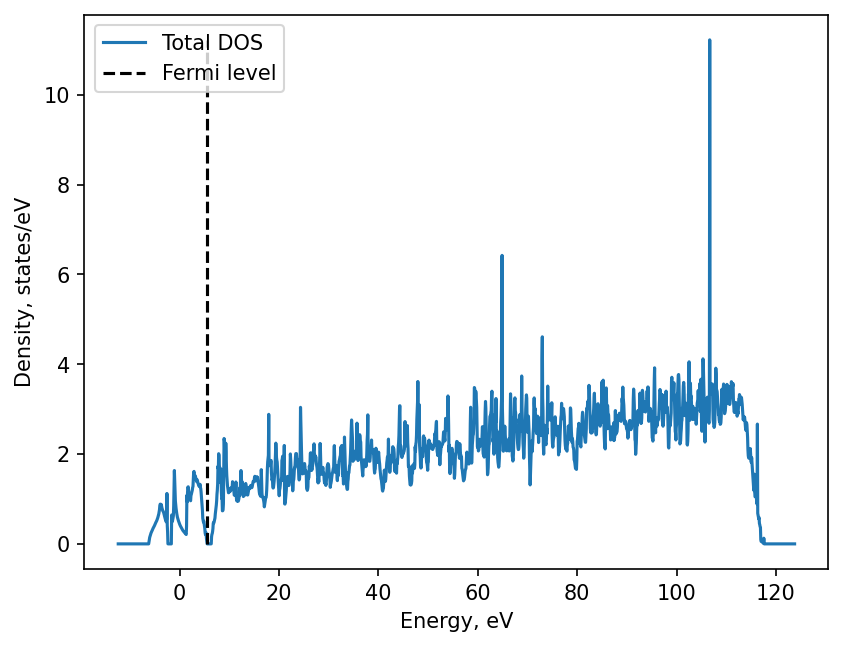

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(dpi = 150)

energies = dos.energies
density_up = dos.as_dict()['densities']['1']

efermi = dos.efermi
ax.plot(energies, density_up, label = 'Total DOS')
ax.set_xlabel('Energy, eV')
ax.set_ylabel('Density, states/eV')
ax.vlines(efermi, min(density_up), max(density_up), color = 'k', linestyle = '--', label = 'Fermi level')
ax.legend()


### Charge density

In [7]:
from mp_api.client import MPRester

with MPRester(api_key) as mpr:
    chgcar = mpr.get_charge_density_from_material_id("mp-149")
data = (chgcar.data['total'] - chgcar.data['diff']) / 2

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving CoreTaskDoc documents:   0%|          | 0/6 [00:00<?, ?it/s]

In [9]:
import numpy as np

coords = np.argwhere(chgcar.data['total'])

In [10]:
x, y, z = coords[0, :], coords[1, :], coords[:, 2]
vol = data.reshape(-1,)

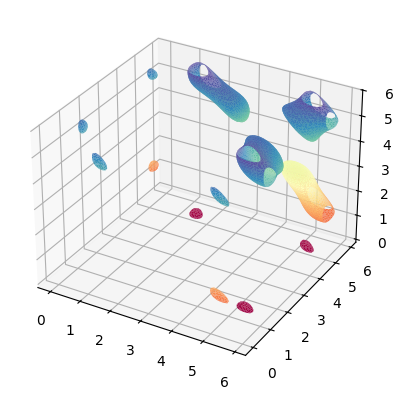

In [11]:
import numpy as np
from numpy import cos, pi
from skimage.measure import marching_cubes
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

iso_val = 10
verts, faces, _, _ = marching_cubes(data, iso_val, spacing=(0.1, 0.1, 0.1))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(verts[:, 0], verts[:,1], faces, verts[:, 2], cmap='Spectral',
                lw=1)
plt.show()

### Phonons band structure

In [12]:
from mp_api.client import MPRester

with MPRester(api_key) as mpr:
    ph_bs = mpr.get_phonon_bandstructure_by_material_id("mp-149")

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
#ph_bs.as_dict().keys()

In [ ]:
# ph_bs.eigendisplacements

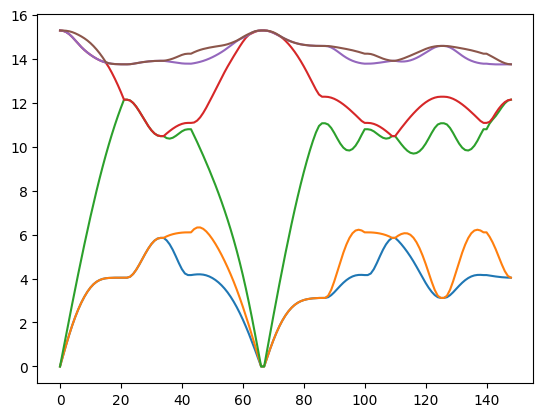

In [15]:

for q, band in zip(ph_bs.qpoints, ph_bs.frequencies):
    plt.plot(band)



### Phonon density of states

In [17]:
from mp_api.client import MPRester
#from emmet.core.electronic_structure import BSPathType

with MPRester(api_key) as mpr:
    ph_dos = mpr.get_phonon_dos_by_material_id("mp-149")

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

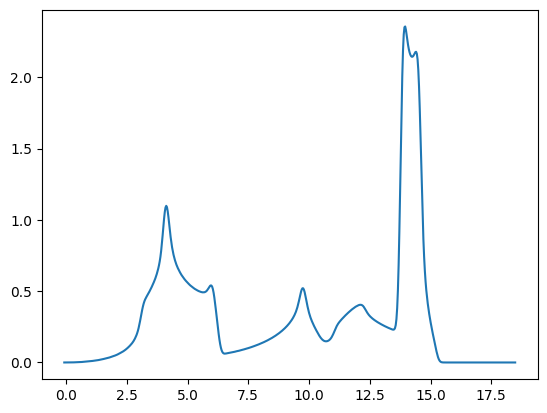

In [18]:
plt.plot(ph_dos.frequencies, ph_dos.densities)

## Task solutions

In [ ]:
# Task 1

keys = [
"material_id",
"band_gap",
"chemsys",
"energy_per_atom",
"uncorrected_energy_per_atom",
"structure",
"composition",
"formula_pretty",
"formation_energy_per_atom",
"nsites",
"energy_above_hull",
]


table = pd.DataFrame()

for key in keys:
    table[key] = [getattr(d, key) for d in docs]


# Task 2

table_grouped = table.sort_values(by = 'energy_per_atom').groupby(by = 'formula_pretty').first()

# Task 3
def calculate_formation_energy(structure, energy_per_atom, terminal_elements_energies):

    """
    This function calculates the formation energy of a given structure

    Params
    ------

    structure: pymatgen's Structure object
        system for which the formation energy is calculated

    energy_per_atom: float
        the calculated total energy of the system
        divided by number of atoms in the structure

    terminal_elements_energies: dictionary
        dictionary with elements and corresponding total energies, e.g. {'Li', -3.3, 'O': -9.1}


    Returns
    -------

    formation energy of the given system

    """
    e_total = energy_per_atom * len(structure)
    e_formation = e_total
    for site in structure.sites:
        e_formation -= terminal_elements_energies[site.specie.symbol]
    return e_formation/len(structure)

formation_energy = []
for st, epa in zip(table_grouped.structure, table_grouped.uncorrected_energy_per_atom):
    formation_energy.append(calculate_formation_energy(st, epa, terminal_elements_energies))



# Task 4

